In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('/content/flipkart_com-ecommerce_sample.csv') # Step 1: Load dataset

In [13]:
print(df.columns)
print(df.head()) # Step 2: View structure

Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='object')
                            uniq_id            crawl_timestamp  \
0  c2d766ca982eca8304150849735ffef9  2016-03-25 22:59:23 +0000   
1  7f7036a6d550aaa89d34c77bd39a5e48  2016-03-25 22:59:23 +0000   
2  f449ec65dcbc041b6ae5e6a32717d01b  2016-03-25 22:59:23 +0000   
3  0973b37acd0c664e3de26e97e5571454  2016-03-25 22:59:23 +0000   
4  bc940ea42ee6bef5ac7cea3fb5cfbee7  2016-03-25 22:59:23 +0000   

                                         product_url  \
0  http://www.flipkart.com/alisha-solid-women-s-c...   
1  http://www.flipkart.com/fabhomedecor-fabric-do...   
2  http://www.flipkart.com/aw-bellies/p/itmeh4grg...   
3  http://www.flipkart.com/alisha-solid-women-s-c...   
4  http://www.flipkar

In [30]:
earbuds_df = df[df['product_name'].str.contains("earbuds|Earbuds|buds", na=False)] # Step 3: Filter for Wireless Earbuds

In [17]:
earbuds_df.loc[:, 'discounted_price'] = earbuds_df['discounted_price'].replace('[₹,]', '', regex=True).astype(float) # Step 4: Clean price column

In [22]:
earbuds_df = earbuds_df.dropna(subset=['discounted_price'])
# Step 5: Drop missing values in price column

In [23]:
# Step 6: Calculate average competitor price
average_price = earbuds_df['discounted_price'].mean()
print(f"\nAverage Competitor Price: ₹{average_price:.2f}")


Average Competitor Price: ₹22630.00


In [24]:
# Step 7: Estimate our own retail price
production_cost = 900  # Assumed
profit_margin = 0.30
our_price = production_cost * (1 + profit_margin)
print(f"Our Estimated Retail Price: ₹{our_price:.2f}")

Our Estimated Retail Price: ₹1170.00


In [25]:
# Step 8: Comparison
if our_price < average_price:
    print("✅ Our price is competitive.")
else:
    print("⚠️ Consider lowering cost or profit margin.")

✅ Our price is competitive.


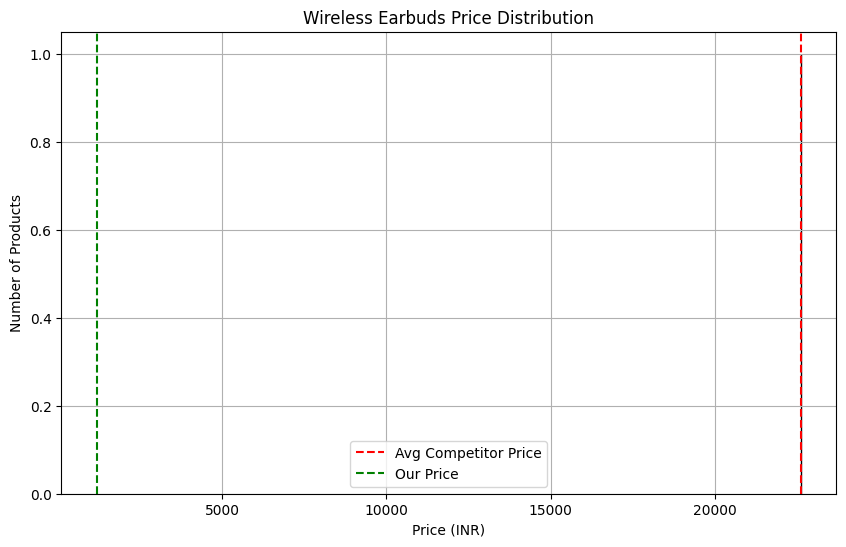

In [26]:
# Step 9: Visualization
plt.figure(figsize=(10, 6))
plt.hist(earbuds_df['discounted_price'], bins=15, color='skyblue', edgecolor='black')
plt.axvline(average_price, color='red', linestyle='--', label='Avg Competitor Price')
plt.axvline(our_price, color='green', linestyle='--', label='Our Price')
plt.title("Wireless Earbuds Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Products")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
print("\n📊 Summary Report")
print("-------------------")
print(f"Market Avg Price: ₹{average_price:.2f}")
print(f"Our Retail Price: ₹{our_price:.2f}")
print("✅ Price is competitive." if our_price < average_price else "⚠️ Price is higher than market average.")



📊 Summary Report
-------------------
Market Avg Price: ₹22630.00
Our Retail Price: ₹1170.00
✅ Price is competitive.


In [28]:
average_price = round(average_price, 2)
our_price = round(our_price, 2)


In [29]:
earbuds_df.to_csv("filtered_earbuds_data.csv", index=False)